# Learned Forward-Backward Splitting for TGV² Denoising

This notebook evaluates an unrolled Forward-Backward Splitting (FBS) algorithm with **learned deviations** for TGV² image denoising.

At each iteration $n$, a CNN predicts deviation vectors $(u_n, v_n)$ that steer the algorithm toward faster convergence, subject to a safeguarding constraint that guarantees the Lyapunov decrease condition is preserved.

We compare three methods:
| Method | Description |
|---|---|
| **Zero deviations** | Base FBS algorithm — $u_n = v_n = 0$ at every step |
| **Learned FBS** | FBS with CNN-predicted deviations (our method) |
| **PDHG** | Standard Primal-Dual Hybrid Gradient solver for TGV² |

**Metrics evaluated:** KKT residual, energy $F(x_n)$, and PSNR vs. iterations.

## 1 — Imports & Problem Setup

We load the problem parameters, build the operator structure (gradient $D$, symmetrised gradient $E$, resolvent $R_A$), and construct the train/test datasets of Shepp-Logan phantoms with random noise levels in $[0.05, 0.2]$.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys, os


sys.path.append(os.path.abspath("../tgv_odl_pghd/denoise"))
sys.path.append(os.path.abspath(".."))

from NN_V9.Algo_setuptorch import Params
from NN_V9.data.dataset import build_train_test_data
from NN_V9.algorithm.unrolled_model import UnrolledFBS
from NN_V9.algorithm.fbs_step import one_step
from NN_V9.plots import *
from NN_V9.run import *
from NN_V9.PSNR import psnr_history
from pghd_denoising import pdhg

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Problem parameters ────────────────────────────────────────────────────
params = Params()
size   = params.size

# Variable blocks: [primal u | dual p | dual q | dual r]
SHAPES = [
    (1, 1, size, size),   # u  — primal image
    (1, 2, size, size),   # p  — dual for Du - w  (2 channels: x, y)
    (1, 2, size, size),   # q
    (1, 3, size, size),   # r  — dual for Ew     (3 channels: xx, yy, xy)
]
N_CH_primal = sum(s[1] for s in SHAPES[:2])  # channels for u and p

# ── Dataset ───────────────────────────────────────────────────────────────
TRAIN_SEEDS = list(range(200))  
TEST_SEEDS = list(range(200,240))

train_data, test_data = build_train_test_data(
    train_seeds=TRAIN_SEEDS,
    test_seeds=TEST_SEEDS,
    params=params,
    device=device,
)
print(f"Train samples: {len(train_data)} | Test samples: {len(test_data)}")

# Pick the first test sample for all experiments
initial_state, clean, functions = test_data[0]

# Sanity check: KKT residual at the noiseless phantom
x_clean = [
    clean.to(device),
    torch.zeros((1, 2, size, size), device=device),
    torch.zeros((1, 2, size, size), device=device),
    torch.zeros((1, 3, size, size), device=device),
]
print(f"KKT residual at clean image: {functions['kkt_residual_norm'](x_clean):.4f}")

Device: cuda
Train samples: 200 | Test samples: 40
KKT residual at clean image: 14.7011


## 2 — Load Trained Model

`UnrolledFBS` unrolls `T` iterations of FBS, with one independent `DeviationNet` per iteration (stored as a `nn.ModuleList` of length `T`). The checkpoint `T` must match the model `T` exactly.

In [2]:
T = 10# number of unrolled iterations (must match training)

model = UnrolledFBS(
    params=params,
    shapes=SHAPES,
    n_channels=N_CH_primal,
    T=T,
    alpha=0.99,
).to(device).float()

checkpoint = torch.load("checkpoint_final_normalise_rand_200epoch.pt", map_location=device)
model.load_state_dict(checkpoint["model"])
model.eval()

train_hist = checkpoint["train_loss_history"]
val_hist   = checkpoint["val_loss_history"]

print(f"Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters")

Model loaded — 600,006 parameters


## 3 — Training History

Loss $= \|\text{KKT residual}\|$ at the last unrolled iteration, averaged over training samples. Train and validation curves should track closely.

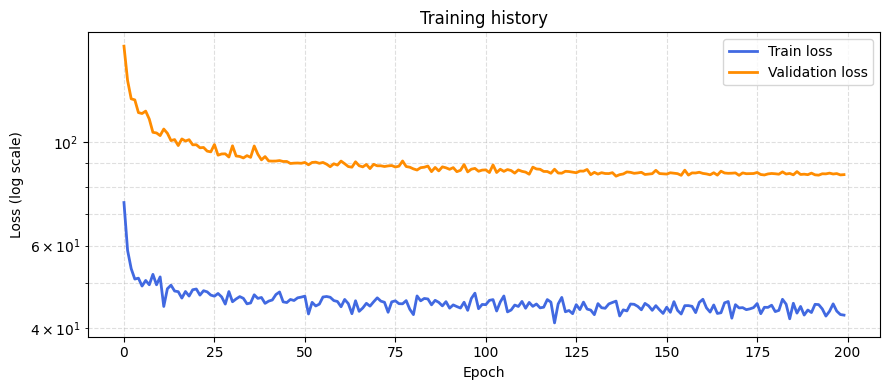

In [3]:
plt.figure(figsize=(9, 4))
plt.semilogy(train_hist, label="Train loss",      color="royalblue",  linewidth=2)
plt.semilogy(val_hist,   label="Validation loss", color="darkorange", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Training history")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("loss_history.png", dpi=150)
plt.show()

## 4 — Convergence Analysis

We run both FBS variants for 100 iterations and plot two convergence indicators on a log-log scale:

- **KKT residual** $\|r_n\|$ — distance to the optimality conditions of the TGV² inclusion
- **Objective value** $F(x_n)$ — value of the TGV² energy functional

Dashed lines show the theoretical rates $O(1/t)$ and $O(1/t^2)$ for reference.

In [4]:
T_test = 100


# Zero-deviation baseline (u_n = v_n = 0 for all n)
F_vals_0, res_0, x_hist = run_zero(initial_state, functions, params, SHAPES, T_test, device)
# Learned FBS (CNN-predicted deviations)
F_vals_CNN, res_CNN, history = run_learned(
    model, initial_state, clean, functions, T_test=T_test, return_all=True
)





iter:0
16.144269943237305
iter:1
18.754201889038086
iter:2
20.940780639648438
iter:3
21.685123443603516
iter:4


21.15432357788086
iter:5
19.886320114135742
iter:6
18.345600128173828
iter:7
16.862071990966797
iter:8
15.587634086608887
iter:9
14.559036254882812
iter:10
13.749727249145508
iter:11
13.09493350982666
iter:12
12.531166076660156
iter:13
12.018424034118652
iter:14
11.534972190856934
iter:15
11.07873821258545
iter:16
10.650355339050293
iter:17
10.25284481048584
iter:18
9.889103889465332
iter:19
9.56201457977295
iter:20
9.272026062011719
iter:21
9.0146484375
iter:22
8.782479286193848
iter:23
8.567523002624512
iter:24
8.364521980285645
iter:25
8.169065475463867
iter:26
7.975915431976318
iter:27
7.784164905548096
iter:28
7.5943684577941895
iter:29
7.407524108886719
iter:30
7.22382116317749
iter:31
7.043293476104736
iter:32
6.865635395050049
iter:33
6.691377639770508
iter:34
6.5200653076171875
iter:35
6.352579593658447
iter:36
6.187929153442383
iter:37
6.026618957519531
iter:38
5.86810827255249
iter:39
5.712094783782959
iter:40
5.5593671798706055
iter:41
5.409588813781738
iter:42
5.2618060111

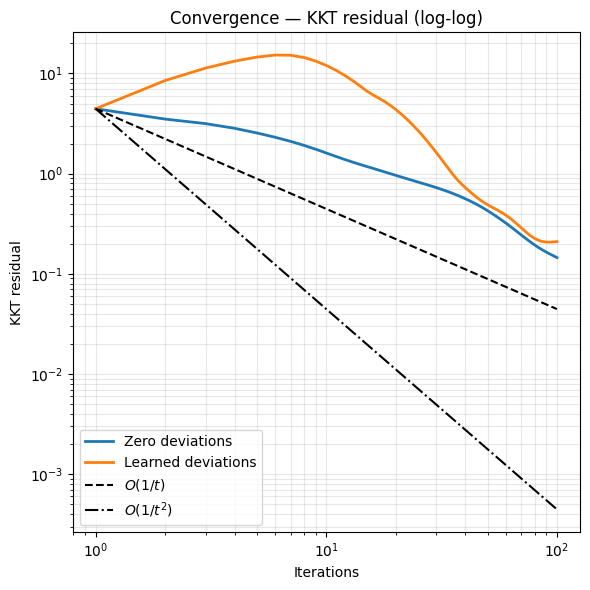

In [5]:
# ── KKT residual ──────────────────────────────────────────────────────────
res_0   = np.array(res_0)
res_CNN = np.array(res_CNN)
iters   = np.arange(1, len(res_0) + 1)

plt.figure(figsize=(6, 6))
plt.loglog(iters, res_0,   label="Zero deviations",    linewidth=2)
plt.loglog(iters, res_CNN, label="Learned deviations", linewidth=2)
plt.loglog(iters, res_0[0] / iters,    "k--", label=r"$O(1/t)$")
plt.loglog(iters, res_0[0] / iters**2, "k-.", label=r"$O(1/t^2)$")
plt.xlabel("Iterations")
plt.ylabel("KKT residual")
plt.title("Convergence — KKT residual (log-log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

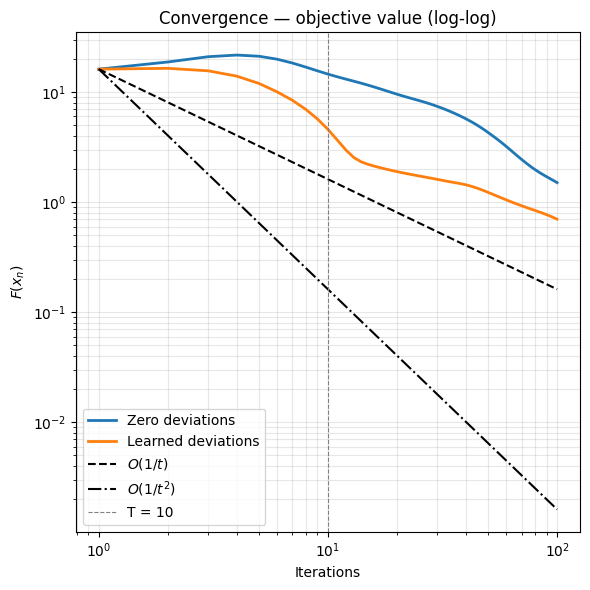

In [6]:
# ── Objective value F(x_n) ────────────────────────────────────────────────
def to_numpy(vals):
    return np.array([
        v.detach().cpu().item() if torch.is_tensor(v) else float(v)
        for v in vals
    ])

gap_0   = np.maximum(to_numpy(F_vals_0),   1e-16)
gap_CNN = np.maximum(to_numpy(F_vals_CNN), 1e-16)
iters   = np.arange(1, len(gap_0) + 1)

plt.figure(figsize=(6, 6))
plt.loglog(iters, gap_0,   label="Zero deviations",    linewidth=2)
plt.loglog(iters, gap_CNN, label="Learned deviations", linewidth=2)
plt.loglog(iters, gap_0[0] / iters,    "k--", label=r"$O(1/t)$")
plt.loglog(iters, gap_0[0] / iters**2, "k-.", label=r"$O(1/t^2)$")

plt.axvline(x=10, color="gray", linewidth=0.8, linestyle="--", label="T = 10")
plt.xlabel("Iterations")
plt.ylabel(r"$F(x_n)$")
plt.title("Convergence — objective value (log-log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 5 — PSNR Comparison

We compare reconstruction quality (PSNR relative to the clean Shepp-Logan phantom) across all three methods at each iteration.

All methods are initialised from the same noisy image so the starting PSNR is identical. PDHG is an independent solver that does not use the unrolled FBS structure — it converges to the same TGV² minimiser but may take more iterations.

In [7]:
# ── Learned FBS — PSNR from stored iteration history ─────────────────────
psnr_learned = psnr_history(history["x"], clean)

# ── Zero deviations — collect per-iteration primal iterates ───────────────
psnr_zero = psnr_history(x_hist, clean)




# ── PDHG ──────────────────────────────────────────────────────────────────
data = initial_state.detach().cpu().squeeze().numpy()
_, _, x_iterates = pdhg(data, T_test)

x_list    = [
    torch.tensor(np.array(xi), dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    for xi in x_iterates
]
psnr_pdhg = psnr_history(x_list, clean.cpu())

iter = 0
Iter 1: F(x) = 108.611794
iter = 1
Iter 2: F(x) = 76.375986
iter = 2
Iter 3: F(x) = 73.161445
iter = 3
Iter 4: F(x) = 82.083950
iter = 4
Iter 5: F(x) = 84.299216
iter = 5
Iter 6: F(x) = 80.563141
iter = 6
Iter 7: F(x) = 74.626968
iter = 7
Iter 8: F(x) = 69.545279
iter = 8
Iter 9: F(x) = 66.234173
iter = 9
Iter 10: F(x) = 64.197613
iter = 10
Iter 11: F(x) = 62.867414
iter = 11
Iter 12: F(x) = 61.726120
iter = 12
Iter 13: F(x) = 60.678288
iter = 13
Iter 14: F(x) = 59.787342
iter = 14
Iter 15: F(x) = 59.128837
iter = 15
Iter 16: F(x) = 58.645947
iter = 16
Iter 17: F(x) = 58.201013
iter = 17
Iter 18: F(x) = 57.732870
iter = 18
Iter 19: F(x) = 57.260216
iter = 19
Iter 20: F(x) = 56.839735
iter = 20
Iter 21: F(x) = 56.420243
iter = 21
Iter 22: F(x) = 55.978746
iter = 22
Iter 23: F(x) = 55.537786
iter = 23
Iter 24: F(x) = 55.099554
iter = 24
Iter 25: F(x) = 54.666304
iter = 25
Iter 26: F(x) = 54.211033
iter = 26
Iter 27: F(x) = 53.738228
iter = 27
Iter 28: F(x) = 53.235098
iter = 28


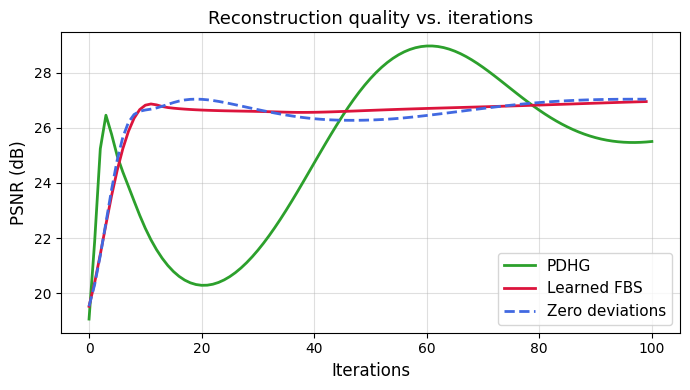


PSNR after 100 iterations:
  Zero deviations : 27.04 dB
  Learned FBS     : 26.96 dB  (-0.09 dB)
  PDHG            : 25.51 dB


In [8]:
plt.figure(figsize=(7, 4))
plt.plot(psnr_pdhg,    label="PDHG",           color="tab:green", linewidth=2)
plt.plot(psnr_learned, label="Learned FBS",     color="crimson",   linewidth=2)
plt.plot(psnr_zero,    label="Zero deviations", color="royalblue", linewidth=2, linestyle="--")
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("PSNR (dB)",  fontsize=12)
plt.title("Reconstruction quality vs. iterations", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("comparison_psnr.pdf", bbox_inches="tight")
plt.show()

print(f"\nPSNR after {T_test} iterations:")
print(f"  Zero deviations : {psnr_zero[-1]:.2f} dB")
print(f"  Learned FBS     : {psnr_learned[-1]:.2f} dB  ({psnr_learned[-1]-psnr_zero[-1]:+.2f} dB)")
print(f"  PDHG            : {psnr_pdhg[-1]:.2f} dB")